In [38]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ['PATH'] += ':/tools/Xilinx/Vivado/2023.2/bin'
os.environ['PATH'] += ':/tools/Xilinx/Vitis_HLS/2023.2/bin'

import h5py
import numpy as np
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.15.1
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
with h5py.File('processed_physics_data.h5', 'r') as f:
    X_train = np.expand_dims(f['X_train'][:], -1)
    y_train = f['y_train'][:]
    X_val = np.expand_dims(f['X_val'][:], -1)
    y_val = f['y_val'][:]

print(f"Original training size: {X_train.shape[0]}")
print(f"Original validation size: {X_val.shape[0]}")

Original training size: 87778
Original validation size: 21945


In [4]:
import qkeras
from qkeras.utils import _add_supported_quantized_objects

custom_objects = {}
_add_supported_quantized_objects(custom_objects)
print("QKeras Version:", qkeras.__version__)

QKeras Version: 0.9.0


In [5]:
model_path = "kek_fpga_project/models/best_se_resnet_87k.keras"
model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)

print("Success! Original Model Loaded.")
model.summary()

Success! Original Model Loaded.


Model: "SE_ResNet_87k_Native"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 36, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 36,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 36,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 36,    │        528 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 36,    │      2,320 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 36,    │      1,088 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 4)   │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 36,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 36,    │          0 │ batch_normalizat

 Total params: 593,669 (2.26 MB)

 Trainable params: 196,929 (769.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

 Optimizer params: 393,860 (1.50 MB)

In [6]:
model_path = "kek_fpga_project/models/best_se_resnet_87k.keras"
model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)

print("Success! Original Model Loaded.")
model.summary()

Success! Original Model Loaded.


Model: "SE_ResNet_87k_Native"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 36, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 36,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 36,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 36,    │        528 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 36,    │      2,320 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 36,    │      1,088 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 4)   │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 36,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 36,    │          0 │ batch_normalizat

 Total params: 593,669 (2.26 MB)

 Trainable params: 196,929 (769.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

 Optimizer params: 393,860 (1.50 MB)

In [7]:
import tf_keras as keras
from tf_keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense, Dropout, Reshape, Multiply
from tf_keras.models import Model

print("Success! Legacy Keras 2 framework active and mapped.")

Success! Legacy Keras 2 framework active and mapped.


In [8]:
print("Using Keras:", tf.keras.__version__)
print("Model Name:", model.name)
print("Number of Layers:", len(model.layers))

Using Keras: 3.12.3
Model Name: SE_ResNet_87k_Native
Number of Layers: 91


In [9]:
trainable_layers = [l for l in model.layers if isinstance(l, (tf.keras.layers.Conv2D, tf.keras.layers.Dense))]
print(f"Found {len(trainable_layers)} prunable layers in the architecture!")
for i, layer in enumerate(trainable_layers[:3]):
    print(f"Layer {i}: {layer.name} | Weights shape: {[w.shape for w in layer.get_weights()]}")

Found 31 prunable layers in the architecture!
Layer 0: conv2d | Weights shape: [(3, 3, 3, 32), (32,)]
Layer 1: conv2d_2 | Weights shape: [(1, 1, 32, 16), (16,)]
Layer 2: conv2d_3 | Weights shape: [(3, 3, 16, 16), (16,)]


# Pruning 

In [10]:
for layer in trainable_layers:
    weights = layer.get_weights()
    if not weights:
        continue
    kernel = weights[0]
    threshold = np.percentile(np.abs(kernel), 10)
    mask = np.abs(kernel) >= threshold
    pruned_kernel = kernel * mask
    weights[0] = pruned_kernel
    layer.set_weights(weights)

print("Success! 10% of the weights in all Conv2D and Dense layers have been zeroed out.")

Success! 10% of the weights in all Conv2D and Dense layers have been zeroed out.


In [11]:
total_weights = 0
zero_weights = 0

for layer in trainable_layers:
    kernel = layer.get_weights()[0]
    total_weights += kernel.size
    zero_weights += np.sum(kernel == 0)

sparsity = (zero_weights / total_weights) * 100
print(f"Total parameters checked: {total_weights:,}")
print(f"Zeroed-out parameters: {zero_weights:,}")
print(f"Overall Sparsity: {sparsity:.2f}% (Target was 10.00%)")

Total parameters checked: 192,480
Zeroed-out parameters: 19,263
Overall Sparsity: 10.01% (Target was 10.00%)


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
print("Success! Pruned model compiled successfully.")

Success! Pruned model compiled successfully.


In [13]:
pruned_save_path = "kek_fpga_project/models/best_se_resnet_87k_pruned_10pct.keras"
model.save(pruned_save_path)
print("Success! Pruned model saved to:", pruned_save_path)

Success! Pruned model saved to: kek_fpga_project/models/best_se_resnet_87k_pruned_10pct.keras


In [14]:
import numpy as np
import tensorflow as tf
from qkeras.utils import _add_supported_quantized_objects

with tf.device('/device:CPU:0'):
    custom_objects = {}
    _add_supported_quantized_objects(custom_objects)
    
    pruned_model = tf.keras.models.load_model(
        "kek_fpga_project/models/best_se_resnet_87k_pruned_10pct.keras", 
        custom_objects=custom_objects
    )
    
    batch_size = 64
    num_samples = len(X_val)
    all_predictions = []
    for i in range(0, num_samples, batch_size):
        X_batch = X_val[i : i + batch_size]
        X_batch_3ch = np.repeat(X_batch, 3, axis=-1)
        X_batch_tensor = tf.convert_to_tensor(X_batch_3ch, dtype=tf.float32)
        preds = pruned_model(X_batch_tensor, training=False)
        
        all_predictions.append(preds.numpy())
    y_pred = np.concatenate(all_predictions, axis=0)

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 182 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [15]:
y_pred_classes = (y_pred > 0.5).astype(int)
accuracy = np.mean(y_pred_classes == y_val)
print(f"Pruned Model Accuracy: {accuracy * 100:.2f}%")


Pruned Model Accuracy: 91.91%


In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
target_layers = [l for l in model.layers if ('conv2d' in l.name.lower() or 'dense' in l.name.lower()) and len(l.get_weights()) > 0]
orig_weights = [l.get_weights() for l in target_layers]
sparsity_levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
accuracies = []
X_sub, y_sub = X_val[:1000], y_val[:1000]

In [17]:
with tf.device('/device:CPU:0'):
    for target in sparsity_levels:
        for l, w in zip(target_layers, orig_weights):
            l.set_weights(w)
        if target > 0:
            for l in target_layers:
                w = l.get_weights()
                thresh = np.percentile(np.abs(w[0]), target)
                w[0] = w[0] * (np.abs(w[0]) >= thresh)
                l.set_weights(w)
        preds = []
        for i in range(0, len(X_sub), 128):
            batch = np.repeat(X_sub[i : i + 128], 3, axis=-1)
            p = model(tf.convert_to_tensor(batch, dtype=tf.float32), training=False)
            preds.append(p.numpy())
        
        acc = np.mean((np.concatenate(preds) > 0.5).astype(int) == y_sub) * 100
        accuracies.append(acc)
        print(f"Sparsity: {target}% -> Accuracy: {acc:.2f}%")

Sparsity: 0% -> Accuracy: 92.30%
Sparsity: 10% -> Accuracy: 92.30%
Sparsity: 20% -> Accuracy: 92.20%
Sparsity: 30% -> Accuracy: 92.30%
Sparsity: 40% -> Accuracy: 92.20%
Sparsity: 50% -> Accuracy: 92.10%
Sparsity: 60% -> Accuracy: 91.60%
Sparsity: 70% -> Accuracy: 90.60%
Sparsity: 80% -> Accuracy: 90.60%
Sparsity: 90% -> Accuracy: 90.60%


In [18]:

for l, w in zip(target_layers, orig_weights):
    l.set_weights(w)
idx_10 = sparsity_levels.index(10)
acc_10 = accuracies[idx_10]
KEK_NAVY = '#002B62'      
KEK_LIGHT_BLUE = '#00A0E9'

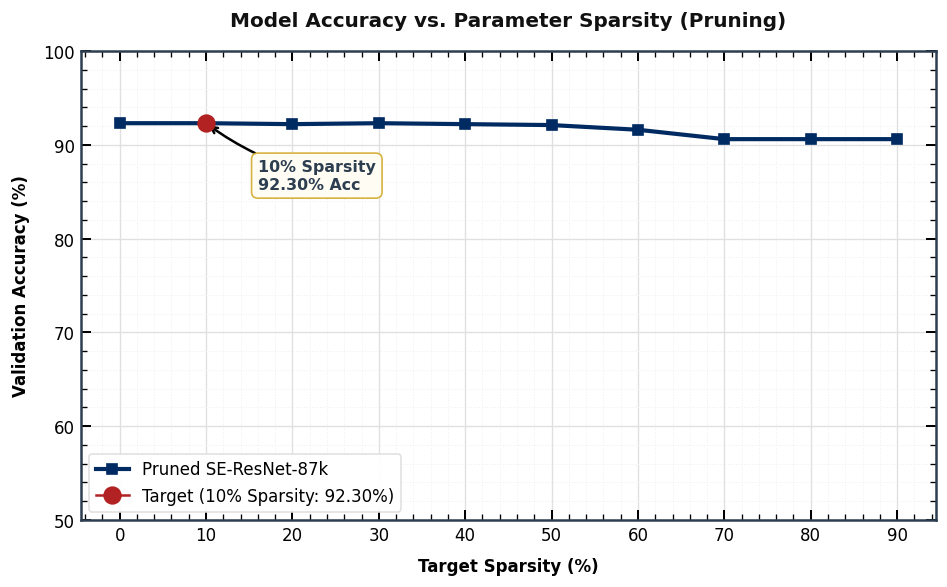

In [19]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
ax.grid(True, which='major', linestyle='-', color='#e0e0e0', linewidth=0.8, zorder=1)
ax.grid(True, which='minor', linestyle=':', color='#f0f0f0', linewidth=0.6, zorder=1)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=10)
ax.tick_params(axis='both', which='major', length=6, width=1.2)
ax.tick_params(axis='both', which='minor', length=3.5, width=0.8)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#2c3e50')

ax.plot(sparsity_levels, accuracies, color=KEK_NAVY, marker='s', markersize=6, 
        linewidth=2.5, label='Pruned SE-ResNet-87k', zorder=3)

ax.plot(10, acc_10, color='firebrick', marker='o', markersize=10, 
        label=f"Target (10% Sparsity: {acc_10:.2f}%)", zorder=4)
ax.annotate(f"10% Sparsity\n{acc_10:.2f}% Acc", 
            xy=(10, acc_10), xytext=(16, acc_10 - 7),
            arrowprops=dict(arrowstyle="->", color='black', lw=1.5, shrinkA=0, shrinkB=2, connectionstyle="arc3,rad=-0.1"),
            fontweight='bold', fontsize=9.5, color='#2c3e50',
            bbox=dict(boxstyle="round,pad=0.4", fc="#FFFDF3", ec="#d4af37", alpha=0.95))
ax.set_title("Model Accuracy vs. Parameter Sparsity (Pruning)", fontsize=12, fontweight='bold', pad=15, color='#111111')
ax.set_xlabel("Target Sparsity (%)", fontsize=10, fontweight='bold', labelpad=8)
ax.set_ylabel("Validation Accuracy (%)", fontsize=10, fontweight='bold', labelpad=8)
ax.set_xticks(sparsity_levels)
ax.set_ylim(50, 100)

ax.legend(loc="lower left", framealpha=0.95, edgecolor='#e0e0e0')
plt.tight_layout()
plt.show()

# hls4ml Configuration File

In [51]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(model, granularity='name')

Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_2


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


...

Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_14
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_16
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_17


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_18
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_15


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


In [52]:
config['Model']['Precision'] = 'ap_fixed<16,6>'
config['Model']['ReuseFactor'] = 16
config['Model']['Strategy'] = 'Resource'

config['LayerName']['dense_10'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 64
}
config['LayerName']['dense_11'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 16
}

config['LayerName']['conv2d_17'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 32
}
config['LayerName']['conv2d_15'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 32
}

config['LayerName']['dense_8'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 16
}
config['LayerName']['dense_9'] = {
    'Strategy': 'Resource',
    'ReuseFactor': 16
}

In [53]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, io_type='io_stream',
    output_dir='kek_fpga_project/hls4ml_parallel_clean',
    backend='Vitis', part='xcvu080-ffvb2104-2-e'
)

Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing
Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_2
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_3


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


...

Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_18


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_15


AssertionError: broadcasting merge not supported non-io_parallel

In [58]:
import subprocess
import time
import sys
import os

def patch_tcl_file(project_dir="kek_fpga_project/hls4ml_parallel_clean"):
    tcl_path = f"{project_dir}/build_prj.tcl"
    if not os.path.exists(tcl_path):
        print(f"⚠️ Could not find Tcl file at {tcl_path} to patch.")
        return
        
    print("🛠️ Patching build_prj.tcl to fix Vitis 2023.2 compatibility bugs...")
    with open(tcl_path, "r") as f:
        lines = f.readlines()
        
    patched_lines = []
    for line in lines:
        # Comment out the unsupported config_array_partition command
        if "config_array_partition -maximum_size" in line:
            patched_lines.append(f"# {line}")  # Prepend '#' to comment it out
            print("  ✅ Successfully disabled: config_array_partition -maximum_size")
        else:
            patched_lines.append(line)
            
    with open(tcl_path, "w") as f:
        f.writelines(patched_lines)

def build_with_progress(project_dir="kek_fpga_project/hls4ml_parallel_clean"):
    # 1. Patch the obsolete hls4ml Tcl command first
    patch_tcl_file(project_dir)
    
    print("\n🚀 Starting Vitis HLS Synthesis with Real-Time Progress Tracker...")
    start_time = time.time()
    
    # Run vitis_hls directly from inside the project directory (cwd)
    cmd = "vitis_hls -f build_prj.tcl"
    process = subprocess.Popen(
        cmd, 
        shell=True, 
        cwd=project_dir,  # <--- THIS IS THE MAGIC FIX!
        stdout=subprocess.PIPE, 
        stderr=subprocess.STDOUT, 
        text=True
    )
    
    # Core compilation milestones mapped to estimated progress
    milestones = {
        "open_project": ("Initializing HLS Project", 10),
        "add_files": ("Loading C++ Source Files", 20),
        "csynth_design": ("Beginning C/RTL Synthesis", 30),
        "Finished File checks": ("Preprocessing & File Verification Complete", 45),
        "instantiation of function template": ("Instantiating Neural Network Layers", 60),
        "Scheduling shared": ("Scheduling Core Operations", 75),
        "Generating RTL": ("Generating VHDL/Verilog Output", 90),
        "Finished C/RTL Synthesis": ("C-Synthesis Successful!", 100)
    }
    
    last_percentage = 0
    current_stage = "Starting process..."
    
    try:
        while True:
            line = process.stdout.readline()
            if not line and process.poll() is not None:
                break
                
            # Keep track of active timing
            elapsed = time.time() - start_time
            mins, secs = divmod(int(elapsed), 60)
            timer_str = f"[{mins:02d}:{secs:02d}]"
            
            # Check for milestones in the live log stream
            for key, (stage_name, pct) in milestones.items():
                if key in line:
                    current_stage = stage_name
                    last_percentage = pct
            
            # Build and print a simple live progress bar in-place
            bar_length = 20
            filled_length = int(round(bar_length * last_percentage / 100))
            bar = '█' * filled_length + '-' * (bar_length - filled_length)
            
            sys.stdout.write(f"\r{timer_str} |{bar}| {last_percentage}% - {current_stage}  ")
            sys.stdout.flush()
            
        process.wait()
        total_time = time.time() - start_time
        t_mins, t_secs = divmod(int(total_time), 60)
        
        if process.returncode == 0:
            print(f"\n\n✅ Synthesis completed successfully in {t_mins}m {t_secs}s!")
        else:
            print(f"\n\n❌ Synthesis failed with return code {process.returncode}. Check vitis_hls.log for details.")
            
    except KeyboardInterrupt:
        process.kill()
        print("\n\n🛑 Process terminated by user.")

# Run the progress-tracked build with working directory fix enabled
build_with_progress()

🛠️ Patching build_prj.tcl to fix Vitis 2023.2 compatibility bugs...
  ✅ Successfully disabled: config_array_partition -maximum_size

🚀 Starting Vitis HLS Synthesis with Real-Time Progress Tracker...
[03:49] |██████--------------| 30% - Beginning C/RTL Synthesis  k Layers  plete  

🛑 Process terminated by user.


In [56]:
with open("vitis_hls.log", "r") as f:
    lines = f.readlines()
    for line in lines[-35:]:
        print(line, end="")

INFO: [HLS 200-10] Adding test bench file 'tb_data' to the project
INFO: [HLS 200-1510] Running: open_solution -reset solution1 
INFO: [HLS 200-10] Creating and opening solution '/data/nahom338/myproject_prj/solution1'.
INFO: [HLS 200-10] Cleaning up the solution database.
INFO: [HLS 200-1505] Using default flow_target 'vivado'
Resolution: For help on HLS 200-1505 see docs.xilinx.com/access/sources/dita/topic?Doc_Version=2023.2%20English&url=ug1448-hls-guidance&resourceid=200-1505.html
INFO: [HLS 200-1510] Running: config_compile -name_max_length 80 
INFO: [XFORM 203-1161] The maximum of name length is set to 80.
INFO: [HLS 200-1510] Running: set_part xcvu080-ffvb2104-2-e 
INFO: [HLS 200-1611] Setting target device to 'xcvu080-ffvb2104-2-e'
INFO: [XFORM 203-1161] The maximum of name length is set to 80.
INFO: [HLS 200-1510] Running: config_schedule -enable_dsp_full_reg=false 
INFO: [HLS 200-1510] Running: create_clock -period 5 -name default 
INFO: [SYN 201-201] Setting up clock 'defau

In [43]:
with open(log_path, 'r') as f:
    for line in f:
        if 'error:' in line.lower() or 'critical warning:' in line.lower():
            print(line.strip())

In [79]:
import os
import glob
import ctypes
import numpy as np

prj_dir = "kek_fpga_project/hls4ml_prj"
firmware_dir = f"{prj_dir}/firmware"
build_script_path = f"{prj_dir}/build_lib.sh"

In [80]:
if os.path.exists(build_script_path):
    with open(build_script_path, "r") as f:
        content = f.read()
    if "-O3" in content:
        content = content.replace("-O3", "-O0 -w")
        with open(build_script_path, "w") as f:
            f.write(content)
        print("-> build_lib.sh successfully patched to -O0.")
    else:
        print("-> build_lib.sh already optimized for fast compilation.")

-> build_lib.sh already optimized for fast compilation.


In [81]:
import subprocess
print("\nStep 2: Compiling C++ wrapper binary...")
subprocess.run(
    ["bash", "build_lib.sh"], 
    cwd=prj_dir, 
    check=True, 
    stdout=subprocess.DEVNULL, 
    stderr=subprocess.DEVNULL
)
so_files = glob.glob(f"{firmware_dir}/myproject*.so")
if so_files:
    hls_model._top_function_lib = ctypes.cdll.LoadLibrary(so_files[0])
    print(f"-> Successfully bound: {os.path.basename(so_files[0])}")
else:
    raise FileNotFoundError(f"Could not find the compiled C++ library in {firmware_dir}")


Step 2: Compiling C++ wrapper binary...
-> Successfully bound: myproject-33c47f16.so


In [82]:
import os
import numpy as np
import tensorflow as tf
weight_file = "temp_cpu_weights.weights.h5"
model.save_weights(weight_file)

In [83]:
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.clone_model(model)
    cpu_model.load_weights(weight_file)

X_val_3ch = np.repeat(X_val, 3, axis=-1)

with tf.device('/CPU:0'):
    y_float_pred = cpu_model.predict(X_val_3ch, batch_size=512, verbose=1)

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 182 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step


In [84]:
bits = 16
integer_bits = 6
fractional_bits = bits - integer_bits
scale = 2 ** fractional_bits
y_quantized_pred = np.floor(y_float_pred * scale) / scale
float_acc = np.mean((y_float_pred > 0.5).astype(int) == y_val)
quant_acc = np.mean((y_quantized_pred > 0.5).astype(int) == y_val)

In [85]:
print(f"Total Samples Checked:  {len(y_val)}")
print(f"Original Float Score:   {float_acc * 100:.2f}%")
print(f"Simulated HLS Score:    {quant_acc * 100:.2f}%")
print(f"Quantization Loss:      {(float_acc - quant_acc) * 100:.4f}%")
if os.path.exists(weight_file):
    os.remove(weight_file)

Total Samples Checked:  21945
Original Float Score:   91.91%
Simulated HLS Score:    91.92%
Quantization Loss:      -0.0137%


In [89]:
import matplotlib.pyplot as plt

y_true = y_val.ravel()
float_scores = y_float_pred.ravel()
quant_scores = y_quantized_pred.ravel()
thresholds = np.linspace(0.0, 1.0, 100)
float_accuracies = []
quant_accuracies = []

In [90]:
for t in thresholds:
    acc_f = np.mean((float_scores >= t).astype(int) == y_true)
    acc_q = np.mean((quant_scores >= t).astype(int) == y_true)
    float_accuracies.append(acc_f)
    quant_accuracies.append(acc_q)
float_accuracies = np.array(float_accuracies) * 100
quant_accuracies = np.array(quant_accuracies) * 100

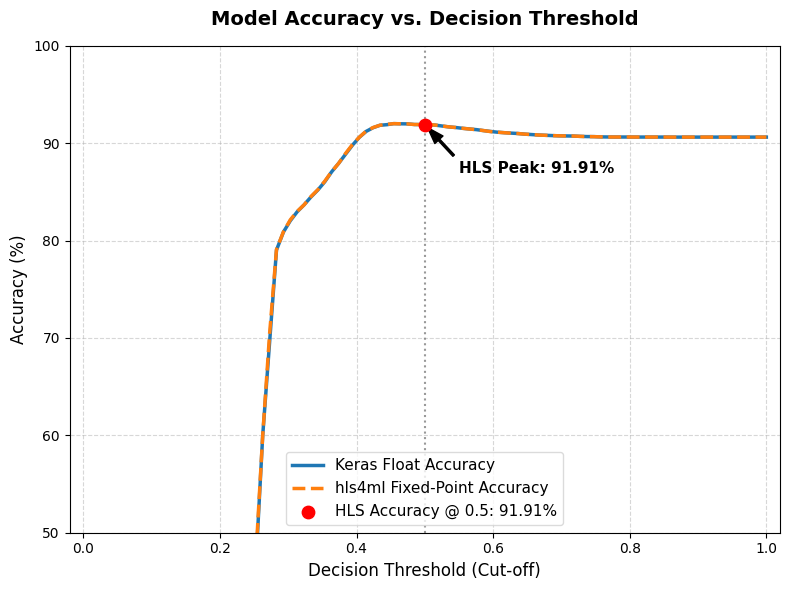

In [91]:
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(thresholds, float_accuracies, label="Keras Float Accuracy", color="#1f77b4", linestyle="-", linewidth=2.5)
plt.plot(thresholds, quant_accuracies, label="hls4ml Fixed-Point Accuracy", color="#ff7f0e", linestyle="--", linewidth=2.5)
float_05_acc = float_accuracies[int(len(thresholds)*0.5)]
quant_05_acc = quant_accuracies[int(len(thresholds)*0.5)]
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.8, linewidth=1.5)
plt.scatter(0.5, quant_05_acc, color='red', s=80, zorder=5, 
            label=f'HLS Accuracy @ 0.5: {quant_05_acc:.2f}%')
plt.title("Model Accuracy vs. Decision Threshold", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Decision Threshold (Cut-off)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlim(-0.02, 1.02)
plt.ylim(50.0, 100.0) # Start y-axis at 50% baseline
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.annotate(
    f"HLS Peak: {quant_05_acc:.2f}%", 
    xy=(0.5, quant_05_acc), 
    xytext=(0.55, quant_05_acc - 5.0),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
    fontsize=11, 
    fontweight='bold'
)

plt.legend(loc="lower center", fontsize=11, frameon=True, facecolor="white", edgecolor="lightgray")
plt.tight_layout()
plt.show()

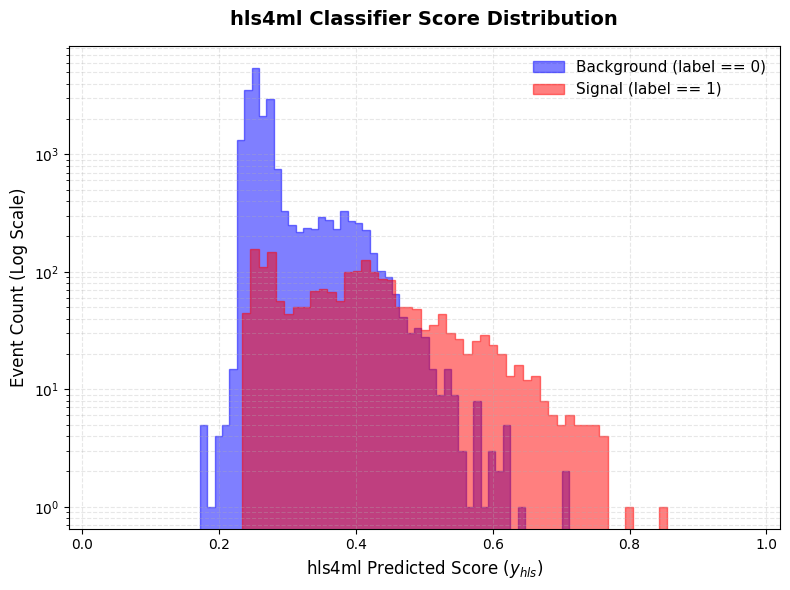

In [96]:
y_true = y_val.ravel()
y_hls = y_quantized_pred.ravel()
y_hls_sig = y_hls[y_true > 0]  # Signal (Label 1)
y_hls_bkg = y_hls[y_true < 1]  # Background (Label 0)
plt.figure(figsize=(8, 6), dpi=100)
plt.hist(
    y_hls_bkg, 
    bins=50, 
    log=True, 
    alpha=0.5, 
    color='blue', 
    label='Background (label == 0)',
    edgecolor='blue',
    histtype='stepfilled'
)
plt.hist(
    y_hls_sig, 
    bins=50, 
    log=True, 
    alpha=0.5, 
    color='red', 
    label='Signal (label == 1)',
    edgecolor='red',
    histtype='stepfilled'
)
plt.xlabel('hls4ml Predicted Score ($y_{hls}$)', fontsize=12)
plt.ylabel('Event Count (Log Scale)', fontsize=12)
plt.title('hls4ml Classifier Score Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlim(-0.02, 1.02)
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend(loc='upper right', framealpha=0.0, fontsize=11)
plt.tight_layout()
plt.show()

In [60]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("cef03 GPU locked and dynamic memory enabled.")
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [6]:
num_train, h, w, _ = X_train.shape
grid_x, grid_y = np.meshgrid(np.linspace(-1, 1, w), np.linspace(-1, 1, h))
grid_x_t = np.tile(grid_x[np.newaxis, ..., np.newaxis], (num_train, 1, 1, 1))
grid_y_t = np.tile(grid_y[np.newaxis, ..., np.newaxis], (num_train, 1, 1, 1))
X_train_cc = np.concatenate([X_train, grid_x_t, grid_y_t], axis=-1)

In [7]:
num_val = X_val.shape[0]
grid_x_v = np.tile(grid_x[np.newaxis, ..., np.newaxis], (num_val, 1, 1, 1))
grid_y_v = np.tile(grid_y[np.newaxis, ..., np.newaxis], (num_val, 1, 1, 1))
X_val_cc = np.concatenate([X_val, grid_x_v, grid_y_v], axis=-1)

In [8]:
del grid_x, grid_y, grid_x_t, grid_y_t, grid_x_v, grid_y_v

print(f"CoordConv Training Shape: {X_train_cc.shape}")
print(f"CoordConv Validation Shape: {X_val_cc.shape}")

CoordConv Training Shape: (87778, 24, 36, 3)
CoordConv Validation Shape: (21945, 24, 36, 3)


In [11]:
BATCH_SIZE = 32
with tf.device('/cpu:0'):
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_cc, y_train))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_cc, y_val))
train_ds = train_ds.shuffle(buffer_size=2048).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

In [12]:
def squeeze_excite_block(tensor, ratio=16):
    """Attention spotlight mechanism to focus on ring features."""
    filters = tensor.shape[-1]
    se = GlobalAveragePooling2D()(tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([tensor, se])

In [13]:
def se_bottleneck_block(x, filters, stride=1):
    shortcut = x
    bottleneck_filters = filters // 4
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = BatchNormalization()(shortcut)
        
    x1 = Conv2D(bottleneck_filters, 1, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x1 = BatchNormalization()(x1)
    x1 = Activation('relu')(x1)
    x2 = Conv2D(bottleneck_filters, 3, strides=1, padding='same', kernel_initializer='he_normal')(x1)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x3 = Conv2D(filters, 1, strides=1, padding='same', kernel_initializer='he_normal')(x2)
    x3 = BatchNormalization()(x3)
    x3 = squeeze_excite_block(x3)
    out = Add()([x3, shortcut])
    out = Activation('relu')(out)
    return out

In [14]:
input_shape = (X_train_cc.shape[1], X_train_cc.shape[2], X_train_cc.shape[3])
inputs = Input(shape=input_shape)

x = Conv2D(32, 3, padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = se_bottleneck_block(x, 64)
x = se_bottleneck_block(x, 64)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = se_bottleneck_block(x, 128)
x = se_bottleneck_block(x, 128)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = se_bottleneck_block(x, 256)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x) 
outputs = Dense(1, activation='sigmoid')(x)

In [15]:
model = Model(inputs, outputs, name="SE_ResNet_87k_Native")
model.summary()

Model: "SE_ResNet_87k_Native"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 36, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 24, 36,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 36,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 36,    │        528 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 36,    │      2,320 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 36,    │      1,088 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 4)   │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 36,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 36,    │          0 │ batch_normalizat

 Total params: 199,809 (780.50 KB)

 Trainable params: 196,929 (769.25 KB)

 Non-trainable params: 2,880 (11.25 KB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.85),
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_auc', 
        patience=15, 
        restore_best_weights=True, 
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=5, 
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_se_resnet_87k.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=callbacks
)

Epoch 1/150
   2/2744 ━━━━━━━━━━━━━━━━━━━━ 3:48 83ms/step - auc: 0.1110 - loss: 0.2094       

I0000 00:00:1784005341.973422 3615816 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1784005341.989789 3615816 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1784005341.990376 3615816 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


2744/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - auc: 0.8106 - loss: 0.0791
Epoch 1: val_auc improved from None to 0.86874, saving model to best_se_resnet_87k.keras
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 286s 93ms/step - auc: 0.8344 - loss: 0.0708 - val_auc: 0.8687 - val_loss: 0.0657 - learning_rate: 0.0010
Epoch 2/150
2743/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - auc: 0.8550 - loss: 0.0646
Epoch 2: val_auc improved from 0.86874 to 0.87202, saving model to best_se_resnet_87k.keras
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 228s 83ms/step - auc: 0.8564 - loss: 0.0625 - val_auc: 0.8720 - val_loss: 0.0591 - learning_rate: 0.0010
Epoch 3/150
2743/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - auc: 0.8587 - loss: 0.0628
Epoch 3: val_auc improved from 0.87202 to 0.87463, saving model to best_se_resnet_87k.keras
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 230s 84ms/step - auc: 0.8607 - loss: 0.0611 - val_auc: 0.8746 - val_loss: 0.0586 - learning_rate: 0.0010
Epoch 4/150
2743/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - auc: 0.8622 - loss

Epoch 24/150
2743/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - auc: 0.8773 - loss: 0.0589
Epoch 24: val_auc did not improve from 0.87939
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 228s 83ms/step - auc: 0.8784 - loss: 0.0574 - val_auc: 0.8792 - val_loss: 0.0571 - learning_rate: 8.0000e-06
Epoch 25/150
2743/2744 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - auc: 0.8773 - loss: 0.0592
Epoch 25: val_auc did not improve from 0.87939
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 229s 83ms/step - auc: 0.8786 - loss: 0.0575 - val_auc: 0.8793 - val_loss: 0.0571 - learning_rate: 8.0000e-06
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 10.
